# Low correlation, $S_{1/2}$
*Warning:* shape of cl_Planck = (Nmaps, Nmasks, lmax)

ToDo:
- Compare Smu (summation) to Smu (Itab) with current setup

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import healpy as hp
import sys
from scipy.special import legendre
%matplotlib inline
%config InlineBackend.figure_format = 'retina'
sys.path.insert(1, '../../scripts')
import CMBanom

In [2]:
# Parameters
Nsims = 100000
Nside = 128
load_stats_from_cluster = True

In [3]:
# Directories
sims_dir = '../../data/sims/sims_1k/'
real_dir = "../../data/real/"
stats_dir = "../../data/stats/"

# Planck maps  
names_Planck  = ["commander_nside_128", "nilc_nside_128", "sevem_nside_128", "smica_nside_128", "v7_70GHz_nside_128", "v7_94GHz_nside_128", "v7_100GHz_nside_128", "v7_143GHz_nside_128"]

labels_Planck = [r"$\mathrm{Commander}$", r"$\mathrm{NILC}$", r"$\mathrm{SEVEM}$", r"$\mathrm{SMICA}$", r"$70\, \mathrm{GHz}$", r"$94\, \mathrm{GHz}$", r"$100\, \mathrm{GHz}$", r"$143\, \mathrm{GHz}$"]
colors        = [  "tab:red", "teal",  "navy",  "gold", "tab:red",    "teal",   "navy",   "gold"]
lss           = [       "--",   "--",    "--",    "--",       "-",       "-",      "-",      "-"]
color_qml     = "green"
label_qml     = r"$\mathrm{Public\ QML-}C_\ell$"
index_Planck  = 0
index_Hayley  = 6
Nmaps = len(names_Planck)

# Masks
names_mask  = [              "fullsky",                "stdmask",                  "commask"]
labels_mask = [r"$\mathrm{Full\ sky}$", r"$\mathrm{Std.\ mask}$", r"$\mathrm{Common\ mask}$"]
colors_mask = [             "tab:blue",                   "navy",                "firebrick"]
Nmasks = len(names_mask)

# Cls
fn_cl_theory = "../../data/real/COM_PowerSpect_CMB-base-plikHM-TTTEEE-lowl-lowE-lensing-minimum-theory_R3.01.txt"
fn_cl_qml    = "../../data/real/COM_PowerSpect_CMB-TT-full_R3.01.txt"

In [4]:
# Font
plt.rc('font',**{'family':'Helvetica','size':20})
plt.rc('text', usetex=True)
font = {'family':'Helvetica',
        'color' : 'black',
        'size'  :  20}

In [5]:
# Same l-range for all Cls
lmax = 384
ll = np.arange(lmax)

In [6]:
# Load Planck Cl (begins with l=0) and correct window fcts. and units, shape: (Nmasks, Nmaps, lmax)
cl_wf_factor = CMBanom.get_cl_wf_factor(Nside)
cl_Planck = np.array([[np.loadtxt(real_dir+"cl_"+names_Planck[n]+"_"+names_mask[m]+".txt").T[1] for m in range(Nmasks)] for n in range(Nmaps)])
cl_Planck[:4] *= cl_wf_factor
cl_Planck[4:] *= 1e6*cl_wf_factor

# Load Planck corr 
theta, cos_theta = np.loadtxt(real_dir+"corr_"+names_Planck[0]+"_"+names_mask[0]+".txt").T[:2]
corr_Planck = np.array([[np.loadtxt(real_dir+"corr_"+names_Planck[n]+"_"+names_mask[m]+".txt").T[2] for m in range(Nmasks)] for n in range(Nmaps)])
#corr_Planck[4:] *= 1e6

In [7]:
# Load theory Cl used to generate (begins with l=2)
dl_theory = np.append(np.zeros(2), np.loadtxt(fn_cl_theory, skiprows=1).T[1])[:lmax]
corr_theory = np.array([CMBanom.corr_from_cl(t, dl_theory/(ll*(ll+1)/(2*np.pi))) for t in theta])

/Users/lherold/Applications/anaconda3/lib/python3.7/site-packages/ipykernel_launcher.py:3: RuntimeWarning: invalid value encountered in true_divide
  This is separate from the ipykernel package so we can avoid doing imports until


In [8]:
# Load QML Cl's (begins with l=2)
dl_qml = np.loadtxt(fn_cl_qml).T[1][:lmax-2]
cl_qml = np.append(np.zeros(2), dl_qml/ll[2:]/(1+ll[2:])*2*np.pi)

# Compute C(theta) from QML Cl's
corr_qml = np.array([CMBanom.corr_from_cl(t, cl_qml) for t in theta])

In [12]:
perc_68_lower = np.array([np.loadtxt(stats_dir+"corr_mean_std_"+names_mask[m]+".npy") for m in range(Nmasks)])

In [13]:
perc_68_lower.shape

(3, 2, 384)

In [11]:
# Get sim envelope
if load_stats_from_cluster:
    #mean_corrs = np.array([np.loadtxt(stats_dir+"corr_mean_std_"+names_mask[m]+".npy")[0] for m in range(Nmasks)])
    #std_corrs = np.array([np.loadtxt(stats_dir+"corr_mean_std_"+names_mask[m]+".npy")[1] for m in range(Nmasks)])
    mean_corrs = np.array([np.loadtxt(stats_dir+"corr_mean_perc_"+names_mask[m]+".npy")[0] for m in range(Nmasks)])
    perc_68_lower = np.array([np.loadtxt(stats_dir+"corr_mean_perc_"+names_mask[m]+".npy")[1] for m in range(Nmasks)])
    perc_68_upper = np.array([np.loadtxt(stats_dir+"corr_mean_perc_"+names_mask[m]+".npy")[2] for m in range(Nmasks)])
    perc_95_lower = np.array([np.loadtxt(stats_dir+"corr_mean_perc_"+names_mask[m]+".npy")[3] for m in range(Nmasks)])
    perc_95_upper = np.array([np.loadtxt(stats_dir+"corr_mean_perc_"+names_mask[m]+".npy")[4] for m in range(Nmasks)])
else: 
    cls,corrs = np.zeros((Nmasks, Nsims, lmax)), np.zeros((Nmasks, Nsims, lmax))
    for m in range(Nmasks):
        corrs[m] = CMBanom.load_corrs(sims_dir, names_mask[m], Nsims)[2]
    mean_corrs = np.mean(corrs, axis=1)
    std_corrs = np.std(corrs, axis=1)
    perc_68_lower = np.percentile(corrs, (100-68.27)/2, axis=1)
    perc_68_upper = np.percentile(corrs, 68.27+(100-68.27)/2, axis=1)
    perc_95_lower = np.percentile(corrs, (100-95.45)/2, axis=1)
    perc_95_upper = np.percentile(corrs, 95.45+(100-95.45)/2, axis=1)

IndexError: index 2 is out of bounds for axis 0 with size 2

## Plot $C(\theta)$

NameError: name 'perc_68_upper' is not defined

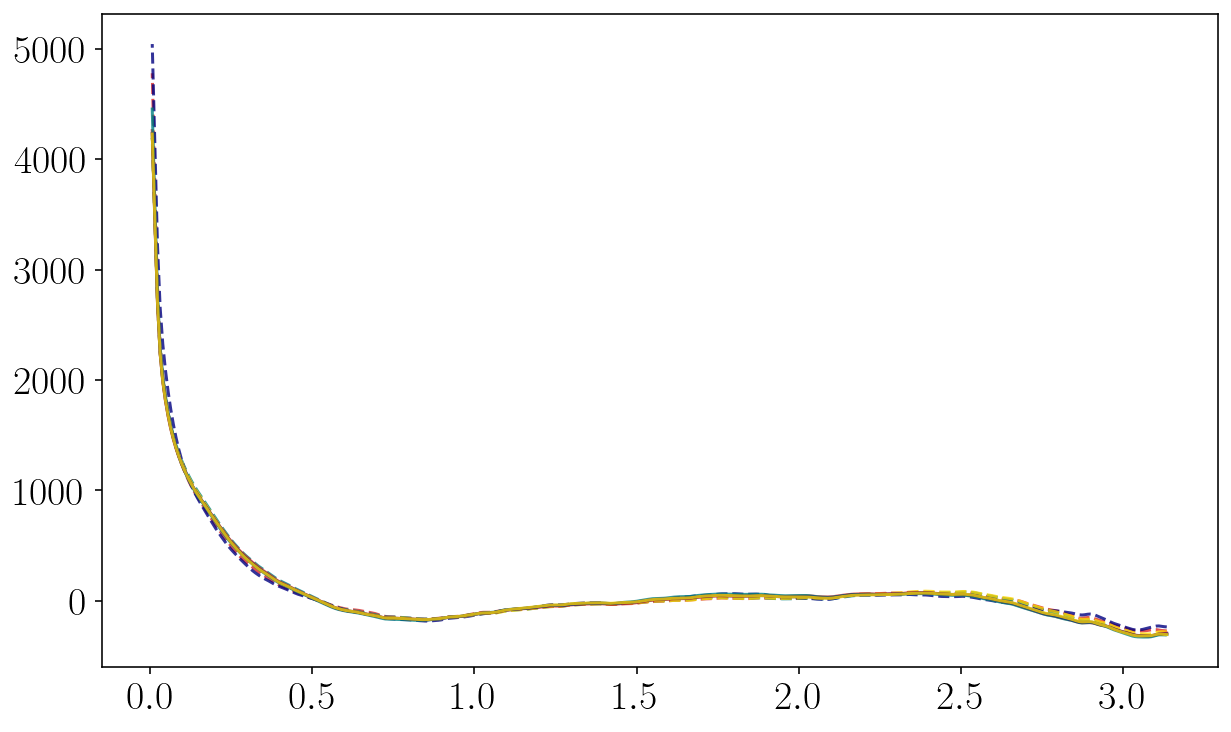

In [14]:
for m in range(Nmasks):
    fig = plt.figure(figsize=(10, 6))
    for n in range(Nmaps):
        plt.plot(theta, corr_Planck[n][m], label=labels_Planck[n], ls=lss[n], color=colors[n], alpha=0.8)
    #plt.fill_between(theta, mean_corrs[m]-std_corrs[m], mean_corrs[m]+std_corrs[m], alpha= 0.2, color=colors_mask[m])
    #plt.fill_between(theta, mean_corrs[m]-2*std_corrs[m], mean_corrs[m]+2*std_corrs[m], alpha= 0.2, color=colors_mask[m])
    plt.fill_between(theta, perc_68_lower[m], perc_68_upper[m], alpha= 0.2, color=colors_mask[m])
    plt.fill_between(theta, perc_95_lower[m], perc_95_upper[m], alpha= 0.2, color=colors_mask[m])
    plt.title(labels_mask[m])
    plt.ylim(-450, 1200)
    plt.xlim(0, np.pi)
    plt.xlabel(r"$\theta$")
    plt.ylabel(r"$C(\theta)\ [\mu K^2]$")
    plt.axhline(0, color="black", lw=0.5)
    plt.axvline(60/180*np.pi, color="grey", ls=":")
    plt.legend()
    plt.savefig(f"corr_{names_mask[m]}.pdf", format="PDF")
    plt.show()

In [ ]:
fig = plt.figure(figsize=(10, 6))
plt.plot([0], [0], color='grey', ls="-", label=r'$100\ \mathrm{GHz}$')
plt.plot([0], [0], color='grey', ls="--", label=r'$\mathrm{Commander}$')
plt.plot(theta, corr_qml, color=color_qml, alpha=0.8, ls=":", lw=3, label=label_qml)

for m in range(Nmasks):
    plt.plot(theta, corr_Planck[index_Hayley][m], color=colors_mask[m], alpha=0.8, ls="-", label=labels_mask[m])
    plt.plot(theta, corr_Planck[index_Planck][m], color=colors_mask[m], alpha=0.8, ls="--")
m = 1
plt.fill_between(theta, perc_68_lower[m], perc_68_upper[m], alpha= 0.2, color=colors_mask[m])
plt.fill_between(theta, perc_95_lower[m], perc_95_upper[m], alpha= 0.2, color=colors_mask[m])
#plt.plot(theta, corr_theory, color=colors_mask[m], ls="-", alpha=0.2, lw=3)
plt.plot(theta, mean_corrs[m], color=colors_mask[m], ls="-", alpha=0.2, lw=3)
plt.ylim(-450, 1200)
plt.xlim(0, np.pi)
plt.xlabel(r"$\theta\,\mathrm{[rad]}$")
plt.ylabel(r"$C(\theta)\ [\mu K^2]$")
plt.axhline(0, color="black", lw=0.5)
plt.axvline(60/180*np.pi, color="grey", ls=":")
plt.legend(loc="upper right", ncol=2)
plt.tight_layout()
#plt.savefig("Corr_fct.pdf", format="PDF")
plt.show()

NameError: name 'perc_68_upper' is not defined

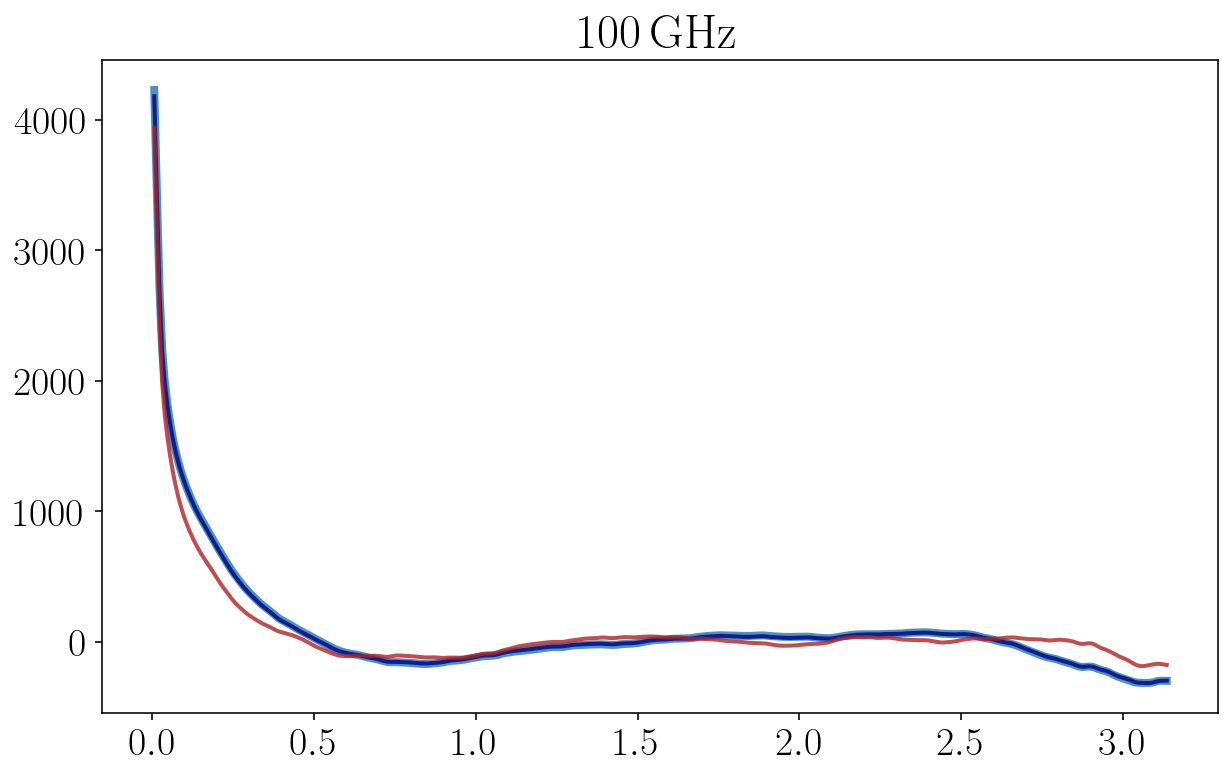

In [15]:
fig = plt.figure(figsize=(10, 6))
plt.title(labels_Planck[index_Hayley])
m = 0
plt.plot([0], [0], color=colors_mask[m], ls="-", label=labels_mask[m], lw=2)
plt.plot(theta, corr_Planck[index_Hayley][m], color=colors_mask[m], alpha=0.8, ls="-", lw=4)
m = 1
plt.plot(theta, corr_Planck[index_Hayley][m], color=colors_mask[m], alpha=0.8, ls="-", label=labels_mask[m], lw=2)
m = 2
plt.plot(theta, corr_Planck[index_Hayley][m], color=colors_mask[m], alpha=0.8, ls="-", label=labels_mask[m], lw=2)
m = 1
plt.fill_between(theta, perc_68_lower[m], perc_68_upper[m], alpha= 0.2, color=colors_mask[m])
plt.fill_between(theta, perc_95_lower[m], perc_95_upper[m], alpha= 0.2, color=colors_mask[m])
plt.plot(theta, corr_qml, color=color_qml, alpha=0.8, ls=":", lw=2, label=label_qml)
plt.plot(theta, mean_corrs[m], color=colors_mask[m], ls="-", alpha=0.2, lw=3)
plt.ylim(-400, 800)
plt.xlim(0, np.pi)
plt.xlabel(r"$\theta\,\mathrm{[rad]}$")
plt.ylabel(r"$C(\theta)\ [\mu K^2]$")
plt.axhline(0, color="black", lw=0.5)
plt.axvline(60/180*np.pi, color="grey", ls=":")
plt.legend(loc="upper center")
plt.tight_layout()
plt.savefig("corr_fct.pdf", format="PDF")
plt.show()

## Plot $S_{1/2}$

In [16]:
if load_stats_from_cluster:
    Smu_sims = [np.loadtxt(stats_dir+f"Smu_sims_{names_mask[m]}_Nsims_{Nsims}.npy") for m in range(Nmasks)]
else:
    Smu_sims = [CMBanom.S_mu_many(corrs[m], cos_theta, 0.5) for m in range(Nmasks)]
Smu_Planck = [CMBanom.S_mu_many(corr_Planck[n], cos_theta, 0.5) for n in range(Nmaps)]
Smu_Planck_QML = CMBanom.S_mu_many([corr_qml], cos_theta, 0.5)

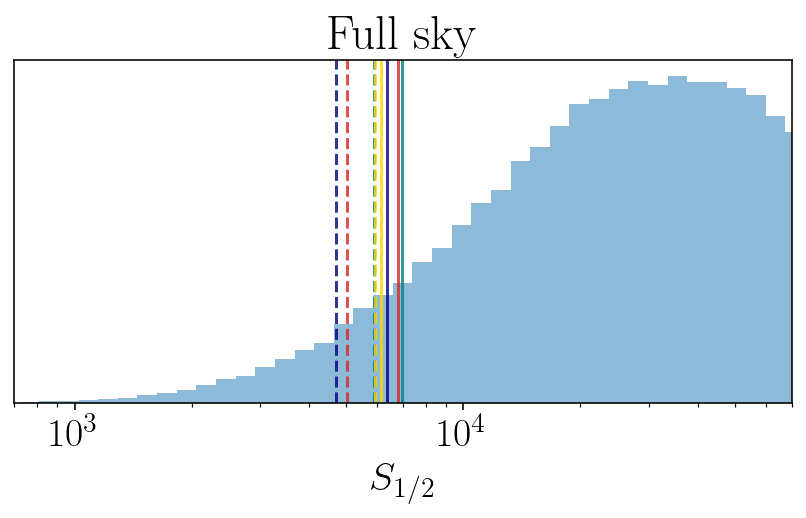

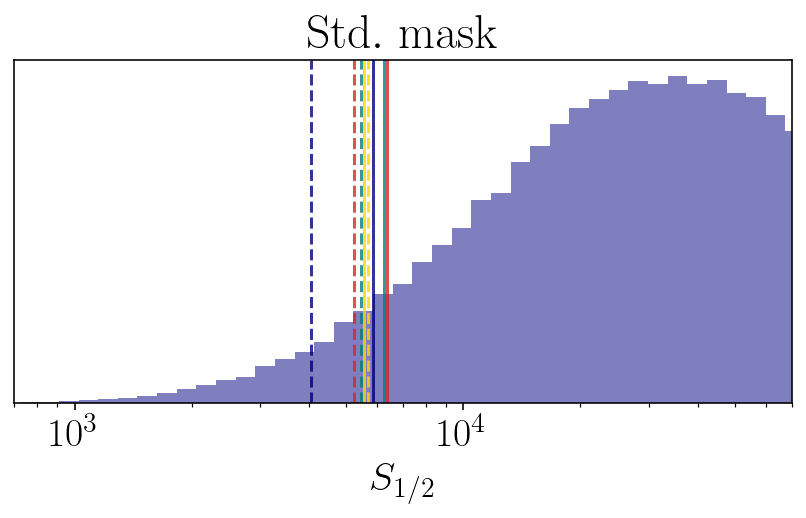

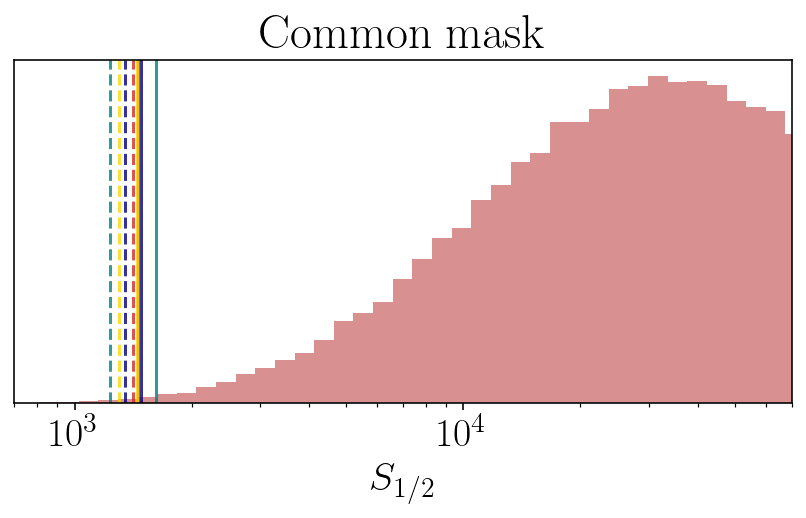

In [17]:
for m in range(Nmasks):
    bins = 10**np.linspace(2, 7, 100)
    h=plt.hist(Smu_sims[m], bins=bins, color=colors_mask[m], alpha=0.5)
    for n in range(Nmaps):
        plt.axvline(Smu_Planck[n][m], color=colors[n], ls=lss[n], label=labels_Planck[n], alpha=0.8)
    plt.title(labels_mask[m])
    plt.xlim(7e2, 7e4)
    plt.xscale("log")
    plt.tick_params(axis='y', which='both', left=False, labelleft=False) 
    plt.xlabel(r"$S_{1/2}$")
    #plt.legend(loc="lower right")
    plt.tight_layout()
    
    #if m==1: plt.legend(loc='center right', bbox_to_anchor=(2.8, 0.5), ncol=4)
    plt.savefig("hist_S_12_"+names_mask[m]+".pdf")
    plt.show()

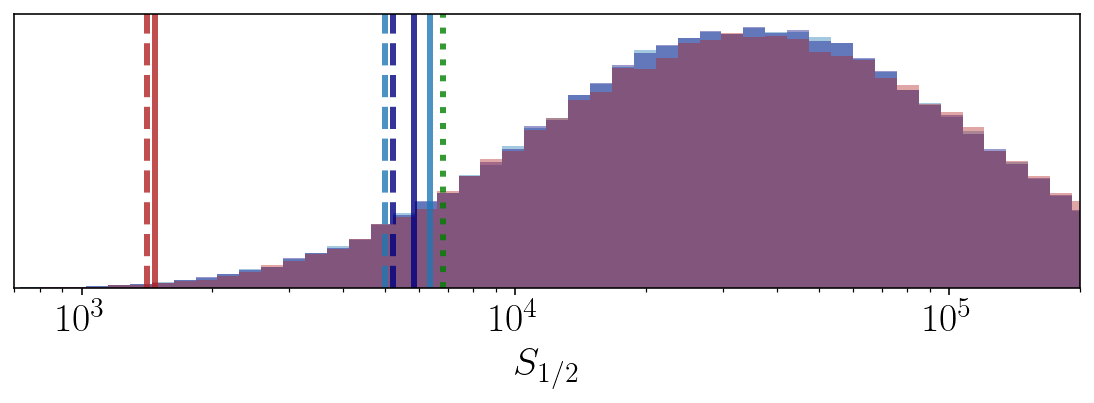

In [18]:
fig = plt.figure(figsize=(8, 3.2))
bins = 10**np.linspace(2, 7, 100)
#plt.plot([0], [0], color='grey', ls="-", lw=3, label=labels_Planck[index_Hayley])
#plt.plot([0], [0], color='grey', ls="--", lw=3, label=labels_Planck[index_Planck])
for m in range(Nmasks):
    h=plt.hist(Smu_sims[m], bins=bins, color=colors_mask[m], alpha=0.4)
    plt.axvline(Smu_Planck[index_Hayley][m], color=colors_mask[m], lw=3, alpha=0.8, ls="-", label=labels_mask[m])
    plt.axvline(Smu_Planck[index_Planck][m], color=colors_mask[m], lw=3, alpha=0.8, ls="--")
plt.axvline(Smu_Planck_QML[0], color=color_qml, lw=3, alpha=0.8, ls=":", label=label_qml)
plt.xlim(7e2, 2e5)
plt.xscale("log")
plt.tick_params(axis='y', which='both', left=False, labelleft=False) 
plt.xlabel(r"$S_{1/2}$")
#plt.legend(loc='center right', bbox_to_anchor=(2.8, 0.5), ncol=1)
#plt.legend(loc="lower right")
plt.tight_layout()
plt.savefig("hist_S_12.pdf", format="PDF")
plt.show()

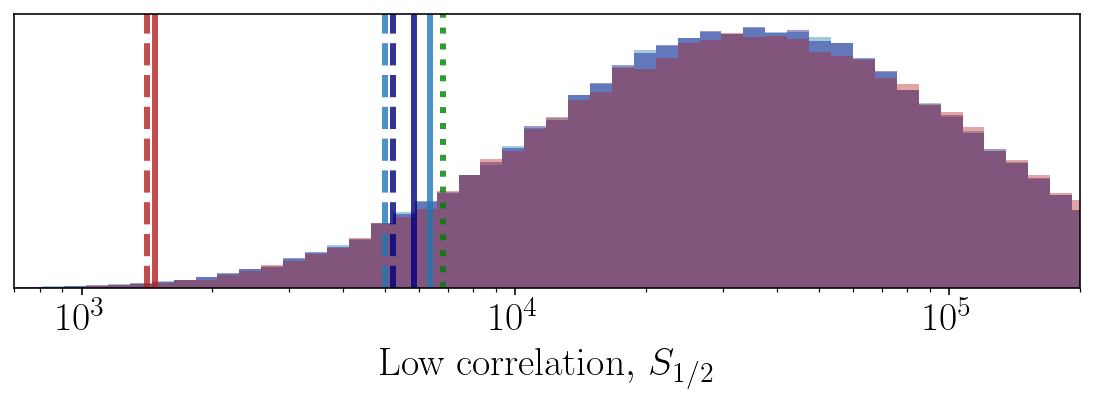

In [19]:
fig = plt.figure(figsize=(8, 3.2))
bins = 10**np.linspace(2, 7, 100)
plt.plot([0], [0], color='grey', ls="-", lw=3, label=labels_Planck[index_Hayley])
plt.plot([0], [0], color='grey', ls="--", lw=3, label=labels_Planck[index_Planck])
for m in range(Nmasks):
    h=plt.hist(Smu_sims[m], bins=bins, color=colors_mask[m], alpha=0.4)
    plt.axvline(Smu_Planck[index_Hayley][m], color=colors_mask[m], lw=3, alpha=0.8, ls="-")
    plt.axvline(Smu_Planck[index_Planck][m], color=colors_mask[m], lw=3, alpha=0.8, ls="--")
plt.axvline(Smu_Planck_QML[0], color=color_qml, lw=3, alpha=0.8, ls=":")
plt.xlim(7e2, 2e5)
plt.xscale("log")
plt.tick_params(axis='y', which='both', left=False, labelleft=False) 
plt.xlabel(r"$\mathrm{Low\ correlation,\ } S_{1/2}$")
#plt.legend(loc="lower right")
plt.tight_layout()
plt.savefig("hist_S_12.pdf", format="PDF")
#plt.legend(loc='center right', bbox_to_anchor=(1.5, 0.5), ncol=1)
plt.show()

## Compute p-values (in %)

In [20]:
print("-----------")
for m in range(Nmasks):
    print(names_mask[m])
    print("-----------")
    for n in range(Nmaps):
        print(f"{Smu_Planck[n][m]:.0f}, p = {100*CMBanom.pval_lower(Smu_Planck[n][m], Smu_sims[m]):.2f}% ({names_Planck[n]})")
    print("-----------")

-----------
fullsky
-----------
5009, p = 4.56% (commander_nside_128)
5892, p = 6.15% (nilc_nside_128)
4690, p = 4.02% (sevem_nside_128)
5922, p = 6.20% (smica_nside_128)
6773, p = 7.78% (v7_70GHz_nside_128)
6965, p = 8.12% (v7_94GHz_nside_128)
6350, p = 6.99% (v7_100GHz_nside_128)
6145, p = 6.62% (v7_143GHz_nside_128)
-----------
stdmask
-----------
5227, p = 4.95% (commander_nside_128)
5461, p = 5.36% (nilc_nside_128)
4050, p = 3.00% (sevem_nside_128)
5675, p = 5.77% (smica_nside_128)
6377, p = 7.04% (v7_70GHz_nside_128)
6243, p = 6.79% (v7_94GHz_nside_128)
5837, p = 6.03% (v7_100GHz_nside_128)
5562, p = 5.55% (v7_143GHz_nside_128)
-----------
commask
-----------
1415, p = 0.17% (commander_nside_128)
1232, p = 0.10% (nilc_nside_128)
1351, p = 0.14% (sevem_nside_128)
1300, p = 0.12% (smica_nside_128)
1453, p = 0.18% (v7_70GHz_nside_128)
1619, p = 0.25% (v7_94GHz_nside_128)
1479, p = 0.19% (v7_100GHz_nside_128)
1446, p = 0.18% (v7_143GHz_nside_128)
-----------


In [21]:
print("p-values")
for m in range(Nmasks):
    print(names_mask[m],": ", end="")
    for n in range(Nmaps):
        print(f"&{100*CMBanom.pval_lower(Smu_Planck[n][m],Smu_sims[m]):.2f} ", end="")
    print("\\\\")

p-values
fullsky : &4.56 &6.15 &4.02 &6.20 &7.78 &8.12 &6.99 &6.62 \\
stdmask : &4.95 &5.36 &3.00 &5.77 &7.04 &6.79 &6.03 &5.55 \\
commask : &0.17 &0.10 &0.14 &0.12 &0.18 &0.25 &0.19 &0.18 \\


In [22]:
print("stats")
for m in range(Nmasks):
    print(names_mask[m],": ", end="")
    for n in range(Nmaps):
        print(f"&{Smu_Planck[n][m]:.0f} ", end="")
    print("\\\\")

stats
fullsky : &5009 &5892 &4690 &5922 &6773 &6965 &6350 &6145 \\
stdmask : &5227 &5461 &4050 &5675 &6377 &6243 &5837 &5562 \\
commask : &1415 &1232 &1351 &1300 &1453 &1619 &1479 &1446 \\
